<a href="https://colab.research.google.com/github/ANURAG-SINGH17/Spam-Classifier/blob/main/Email_Spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv',encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

##DATA CLEANING


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# drop last 3 column
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.sample(5)

,v1,v2
212,ham,K:)k:)good:)study well.
2744,ham,"Tick, tick, tick ... Babe"
1161,ham,K. I will sent it again
1794,ham,How much i gave to you. Morning.
2312,spam,tddnewsletter@emc1.co.uk (More games from TheD...


In [8]:
# renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
5381,spam,You have 1 new message. Call 0207-083-6089
323,ham,That would be great. We'll be at the Guild. Co...
2962,ham,You dont know you jabo me abi.
4667,ham,IM REALY SOZ IMAT MY MUMS 2NITE WHAT ABOUT 2MORO
2215,ham,Prabha..i'm soryda..realy..frm heart i'm sory


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#missingvalues
df.isnull().sum()

,0
target,0
text,0


In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

now data cleaning is complete and next part is EDA
## EDA

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['target'].value_counts()

,count
target,
0,4516
1,653


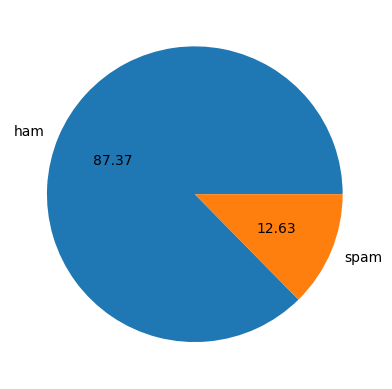

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [ ]:
# Data is imbalanced

In [19]:
pip install nltk

In [20]:
import nltk

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
df['num_Character'] = df['text'].apply(len)

In [23]:
df.head()

,target,text,num_Character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
# num of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_Character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_Character,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_Character','num_words','num_sentences']].describe()

,num_Character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
df[df['target'] == 0][['num_Character','num_words','num_sentences']].describe()

,num_Character,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
df[df['target'] == 1][['num_Character','num_words','num_sentences']].describe()

,num_Character,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [31]:
import seaborn as sns

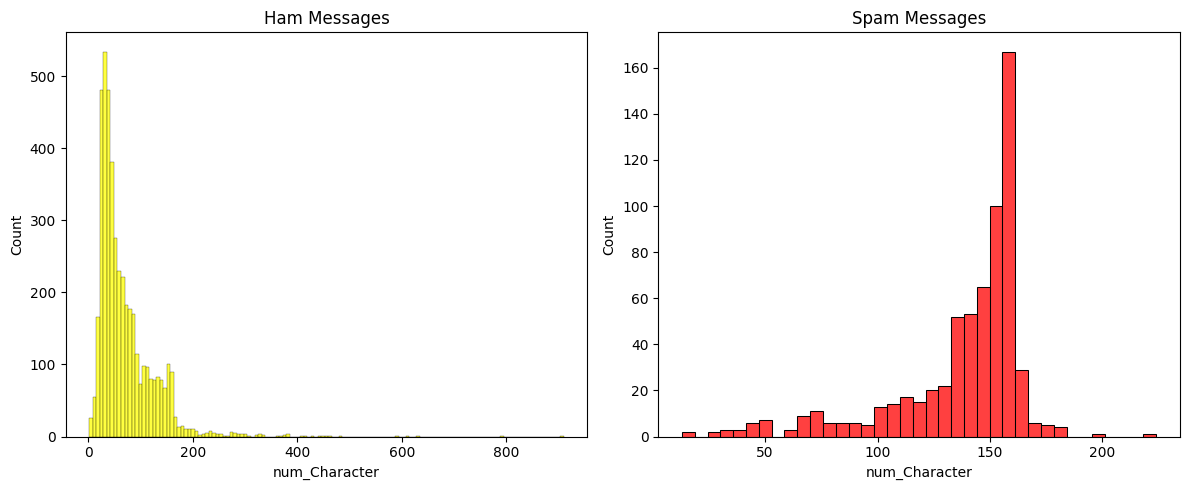

In [32]:
plt.figure(figsize=(12,5))

# First graph
plt.subplot(1,2,1)
sns.histplot(df[df['target'] == 0]['num_Character'], color='yellow')
plt.title('Ham Messages')

# Second graph
plt.subplot(1,2,2)
sns.histplot(df[df['target'] == 1]['num_Character'], color='red')
plt.title('Spam Messages')

plt.tight_layout()
plt.show()

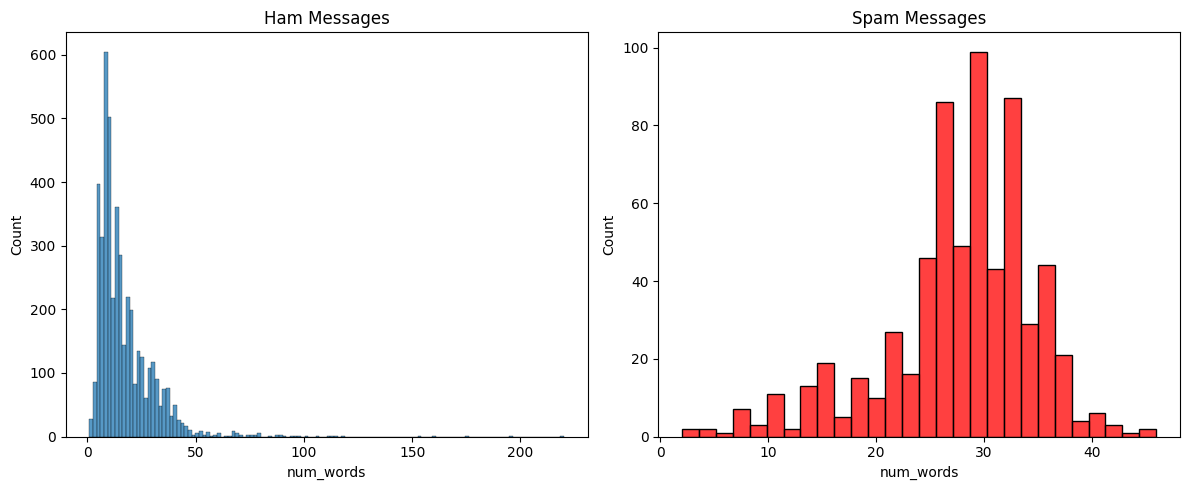

In [33]:
plt.figure(figsize=(12,5))

# First graph
plt.subplot(1,2,1)
sns.histplot(df[df['target'] == 0]['num_words'])
plt.title('Ham Messages')

# Second graph
plt.subplot(1,2,2)
sns.histplot(df[df['target'] == 1]['num_words'], color='red')
plt.title('Spam Messages')

plt.tight_layout()
plt.show()

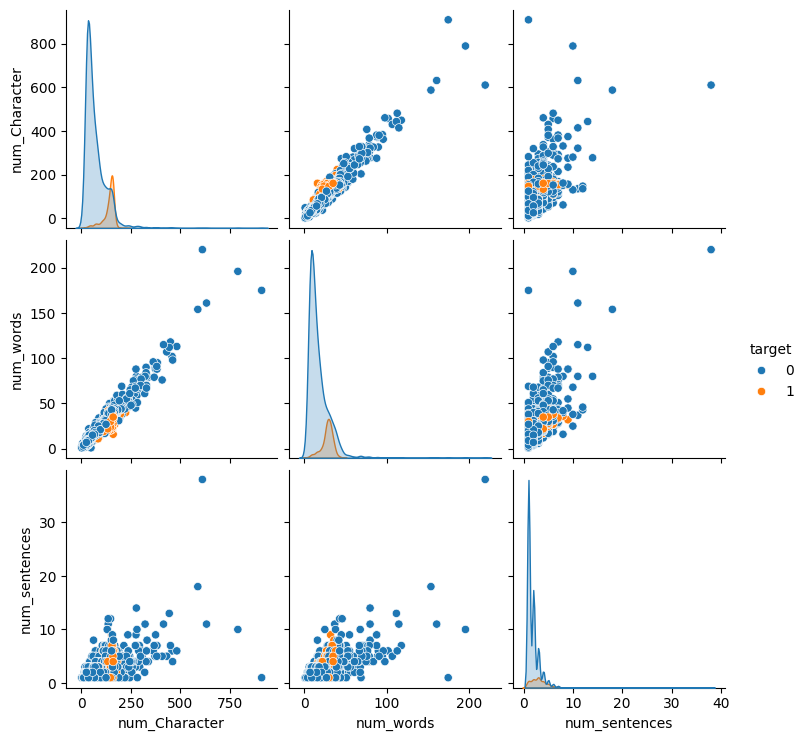

In [34]:
sns.pairplot(df,hue='target')

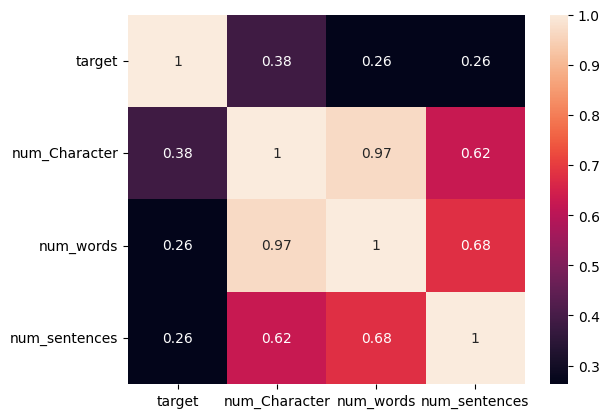

In [35]:
sns.heatmap(df[['target','num_Character','num_words','num_sentences']].corr(),
            annot=True)

plt.show()

Data Preprocessing for NLP
## Data Preprocessing
. Lower case
. Tokenization
. Removing stop words and punctuation
. Stemming

In [41]:
nltk.download('stopwords')
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'danc'

In [42]:
def transform_text(text):
  #lowercase
  text = text.lower()
  #tokenization
  text = nltk.word_tokenize(text)

  #Removing special character
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  # Removing stop words and punctuation
  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
# stemming
  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)


In [43]:
transform_text(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [44]:
df['transform_text'] = df['text'].apply(transform_text)

In [45]:
df.head()

,target,text,num_Character,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [46]:
from wordcloud import WordCloud
wc = WordCloud(width=800,height=800,min_font_size=10,background_color='white')

In [47]:
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep =" "))

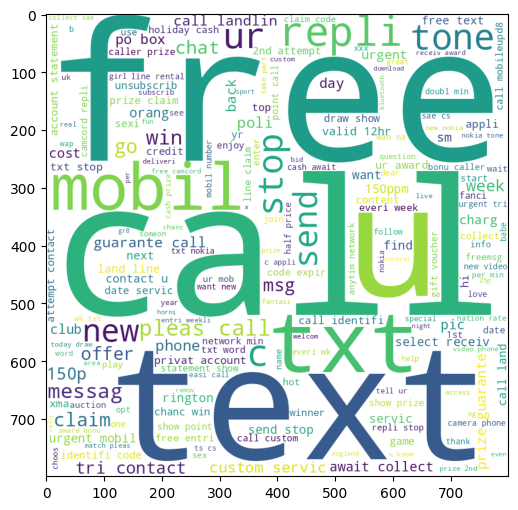

In [48]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

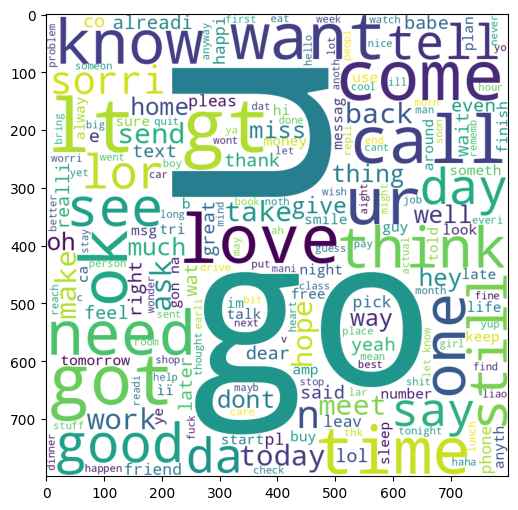

In [49]:
spam_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep =" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [50]:
df.head()

,target,text,num_Character,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [51]:
spam_corpus = []
for msg in df[df['target'] == 1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [52]:
len(spam_corpus)

9939

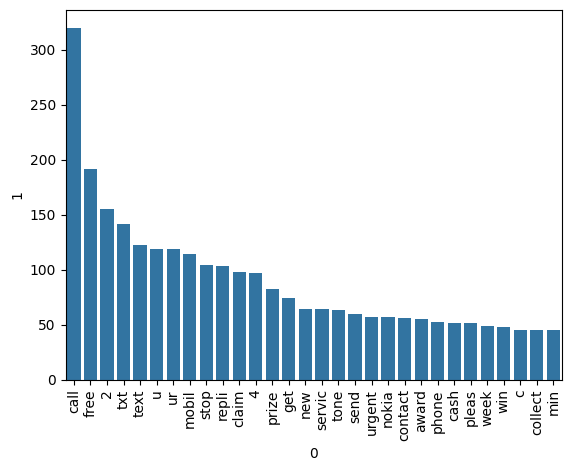

In [53]:
from collections import Counter
temp = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=temp[0], y=temp[1])

plt.xticks(rotation='vertical')
plt.show()


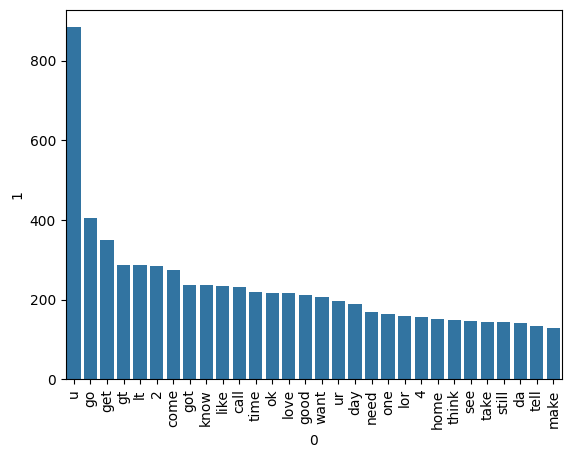

In [54]:
#for ham
spam_corpus = []
for msg in df[df['target'] == 0]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


temp = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=temp[0], y=temp[1])

plt.xticks(rotation='vertical')
plt.show()

## Model Building

In [85]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [114]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [115]:
X.shape

(5169, 3000)

In [116]:
y = df['target'].values

In [117]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [120]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB ,BernoulliNB
from sklearn.metrics import accuracy_score , confusion_matrix,precision_score

In [121]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [122]:
gnb.fit(X_train,y_train)

GaussianNB()

In [123]:
mnb.fit(X_train,y_train)

MultinomialNB()

In [124]:
bnb.fit(X_train,y_train)

BernoulliNB()

In [125]:
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [126]:
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [127]:
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# Tree based models
from sklearn.tree import DecisionTreeClassifier
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
# Ensemble models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
# XGBoost
from xgboost import XGBClassifier

In [71]:
pip install xgboost

In [73]:
# Linear models
lr = LogisticRegression(solver='liblinear',penalty='l1')
# SVM
svc = SVC(kernel='sigmoid', gamma=1.0)
# Tree model
dt = DecisionTreeClassifier(max_depth=5)
# KNN
knn = KNeighborsClassifier()
# Ensemble models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
abc = AdaBoostClassifier(n_estimators=50,random_state=2)
bc = BaggingClassifier(n_estimators=50,random_state=2)
gbc = GradientBoostingClassifier(n_estimators=100,random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
# XGBoost
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [74]:
clfs = {
    "SVC": svc,
    "LR": lr,
    "DT": dt,
    "KNN": knn,
    "RF": rf,
    "AdaBoost": abc,
    "Bagging": bc,
    "GBDT": gbc,
    "ExtraTrees": etc,
    "XGBoost": xgb
}

In [78]:
def train_model(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred)

  return accuracy , precision

In [79]:
train_model(svc,X_train,y_train,X_test,y_test)

(0.9729206963249516, 0.9741379310344828)

In [84]:
accuracy_scores = []
precision_scores = []
model_names = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_model(
        clf, X_train, y_train, X_test, y_test
    )

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    model_names.append(name)


performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

print(performance_df)


        Model  Accuracy  Precision
0         SVC  0.972921   0.974138
1          LR  0.951644   0.940000
2          DT  0.938104   0.862745
3         KNN  0.900387   1.000000
4          RF  0.973888   0.991150
5    AdaBoost  0.924565   0.840909
6     Bagging  0.958414   0.862595
7        GBDT  0.957447   0.912281
8  ExtraTrees  0.972921   0.982456
9     XGBoost  0.974855   0.951613


dict_items([('SVC', SVC(gamma=1.0, kernel='sigmoid')), ('LR', LogisticRegression(penalty='l1', solver='liblinear')), ('DT', DecisionTreeClassifier(max_depth=5)), ('KNN', KNeighborsClassifier()), ('RF', RandomForestClassifier(random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=2)), ('Bagging', BaggingClassifier(n_estimators=50, random_state=2)), ('GBDT', GradientBoostingClassifier(random_state=2)), ('ExtraTrees', ExtraTreesClassifier(n_estimators=50, random_state=2)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_

In [129]:
import pickle

In [130]:
pickle.dump(tfidf,open('vectorize.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))